# Project Title: Calculative Foundation :-

###  Introduction and Data Loading

In [36]:
import pandas as pd
import numpy as np
from scipy.linalg import lu
from sklearn.decomposition import PCA
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis as LDA
import matplotlib.pyplot as plt
import seaborn as sns

In [37]:
# Load dataset & Overview : 
df = pd.read_csv('student_performance_dataset.csv')
print(df.head())

# Statistical Overview
df[['Mathematics', 'Physics', 'Chemistry', 'Computer_Science', 'English']].describe()


  Student_ID  Mathematics  Physics  Chemistry  Computer_Science  English
0    STU_001           77       79         48                88       84
1    STU_002           67       70         60                65       69
2    STU_003           79       86         68                90       75
3    STU_004           92       99         68               100       70
4    STU_005           66       57         62                74       70


,Mathematics,Physics,Chemistry,Computer_Science,English
count,200.000000,200.000000,200.000000,200.00000,200.000000
mean,68.800000,69.245000,66.485000,73.21500,75.760000
std,13.716806,15.430668,11.874967,15.26512,9.541362
min,30.000000,30.000000,38.000000,30.00000,50.000000
25%,59.000000,59.750000,58.000000,62.00000,69.000000
50%,69.500000,71.000000,66.500000,73.00000,76.000000
75%,77.000000,80.000000,74.000000,85.00000,82.000000
max,100.000000,100.000000,100.000000,100.00000,100.000000


> 📊 **Observation:** This line of code successfully loads the student performance CSV file into our workspace and displays the first five student records as an initial data preview. This code calculates the mean, standard deviation, and min/max ranges to show the overall numerical summary of our student subject scores.*

### 📐 Vector Representation of Student Profiles

In [38]:
# Create Student Vectors
subject_columns = ['Mathematics', 'Physics', 'Chemistry', 'Computer_Science', 'English']

student_vectors = df[subject_columns].to_numpy()

print("Each student's scores are now represented as a vector:\n")
for i in range(3):
    student_id = df.loc[i, 'Student_ID']
    print(f"Student {student_id} ka Vector -> {student_vectors[i]}")

Each student's scores are now represented as a vector:

Student STU_001 ka Vector -> [77 79 48 88 84]
Student STU_002 ka Vector -> [67 70 60 65 69]
Student STU_003 ka Vector -> [79 86 68 90 75]


* **In short:** This code extracts individual subject marks and converts them into structured 5-Dimensional NumPy arrays to systematically model each student's academic profile as a spatial coordinate vector.

### 📐 Computation of Vector Norms and Dot Products

In [39]:
# Calculate Vector Metrics
norm_1_values = np.linalg.norm(student_vectors, ord=1, axis=1)
norm_2_values = np.linalg.norm(student_vectors, ord=2, axis=1)

dot_result = np.dot(student_vectors[0], student_vectors[1])

print("--- Analysis Results ---\n")

for i in range(3):
    student_id = df.loc[i, 'Student_ID']
    print(f"Student {student_id} -> Norm-1: {norm_1_values[i]:.2f}, Norm-2: {norm_2_values[i]:.2f}")

print(f"\nDot Product (between Student 0 and Student 1): {dot_result:.2f}")

--- Analysis Results ---

Student STU_001 -> Norm-1: 376.00, Norm-2: 171.10
Student STU_002 -> Norm-1: 331.00, Norm-2: 148.24
Student STU_003 -> Norm-1: 398.00, Norm-2: 178.85

Dot Product (between Student 0 and Student 1): 25085.00


* **In short:** This code computes the absolute total score magnitude (Norm-1), distance profile (Norm-2), and similarity overlap (Dot Product) to quantify individual and relative performance metrics across the cohort vectors.

### 📐 Geometric Vector Metrics: Angles, Cross Products, and Projections

In [40]:
# Compute Geometric Metrics
vector_A = student_vectors[0]
vector_B = student_vectors[1]

dot_prod = np.dot(vector_A, vector_B)
norm_A = np.linalg.norm(vector_A)
norm_B = np.linalg.norm(vector_B)

cosine_theta = dot_prod / (norm_A * norm_B)
angle_radians = np.arccos(np.clip(cosine_theta, -1.0, 1.0))
angle_degrees = np.degrees(angle_radians)

vector_A_3d = vector_A[0:3]
vector_B_3d = vector_B[0:3]
cross_prod_result = np.cross(vector_A_3d, vector_B_3d)

projection_vector = (dot_prod / (norm_B ** 2)) * vector_B

print("--- Geometric and Advanced Vector Operations ---\n")
print(f"Angle between Student 0 and Student 1: {angle_degrees:.2f} degrees")
print(f"Cross Product of 3D subjects (Math, Phys, Chem): {cross_prod_result}")
print(f"Projection of Student 0 onto Student 1: {projection_vector}")

--- Geometric and Advanced Vector Operations ---

Angle between Student 0 and Student 1: 8.50 degrees
Cross Product of 3D subjects (Math, Phys, Chem): [ 1380 -1404    97]
Projection of Student 0 onto Student 1: [76.48213879 79.90671217 68.49146758 74.19908987 78.76518771]


* **In short:** This code maps out the directional alignment angle, spatial variance vector (Cross Product), and relative magnitude shadows (Projection) to build the geometric framework required for dimensionality reduction and classification models like SVD, PCA, and LDA.

### 🗂️ Fundamental Matrix Transformations: Addition and Multiplication

In [41]:
# Perform Matrix Operations
full_matrix = df[['Mathematics', 'Physics', 'Chemistry', 'Computer_Science', 'English']].to_numpy()

matrix_A = full_matrix[0:5, 0:5]

matrix_addition_result = matrix_A + matrix_A

matrix_multiplication_result = np.dot(matrix_A, matrix_A)

print("--- Matrix Addition Result (First 2 rows shown) ---")
print(matrix_addition_result[0:2])

print("\n--- Matrix Multiplication Result (First 2 rows shown) ---")
print(matrix_multiplication_result[0:2])

--- Matrix Addition Result (First 2 rows shown) ---
[[154 158  96 176 168]
 [134 140 120 130 138]]

--- Matrix Multiplication Result (First 2 rows shown) ---
[[28654 29241 22892 31247 27559]
 [25123 25721 20194 27452 24338]]


* **In short:** This code creates a localized 5x5 square subsystem matrix to evaluate basic algebraic scaling (addition) and operational dependency mapping (multiplication) across core subject vectors.

### 🗂️ Advanced Matrix Inversion and Dimensional Transpositions

In [42]:
# Invert and Transpose
matrix_transpose_result = full_matrix.T

matrix_inverse_result = np.linalg.inv(matrix_A)

print("--- Matrix Transpose Result ---")
print(f"Original Full Matrix Shape: {full_matrix.shape}")
print(f"Transposed Matrix Shape: {matrix_transpose_result.shape}")

print("\n--- Matrix Inverse Result (First 2 rows shown) ---")
print(matrix_inverse_result[0:2])

--- Matrix Transpose Result ---
Original Full Matrix Shape: (200, 5)
Transposed Matrix Shape: (5, 200)

--- Matrix Inverse Result (First 2 rows shown) ---
[[ 0.00831802  0.05333479 -0.19945584  0.09874276  0.05240543]
 [-0.00202053  0.01760384  0.07282276 -0.02469367 -0.06825844]]


* **In short:** This code flips our data grid axes to study subject-centric profiles (Transpose) and validates system reversibility (Inverse), laying the algebraic foundation required to compress data via SVD/PCA and draw decision boundaries using LDA.

### ⚖️ System Scaling Assessment: Matrix Determinants

In [43]:
# Compute Matrix Determinant
matrix_determinant_result = np.linalg.det(matrix_A)

print("--- Matrix Determinant Result ---")
print(f"Determinant value of the student matrix: {matrix_determinant_result:.2f}")

--- Matrix Determinant Result ---
Determinant value of the student matrix: -6451774.00


* **In short:** This code calculates the system scaling factor (Determinant) to confirm that our student matrix has non-zero volume and unique information, proving the data stability required to execute advanced SVD matrix factorization, PCA feature compression, and supervised LDA classification.

## 🔹 Part C: Linear Transformations & Geometry

The visual boundaries used to analyze or classify data points change drastically based on how many subjects (dimensions) we select from our dataset:

### 🗺️ Dimensional Breakdown Table

| Geometric Space | Dimensions | Dataset Context (Features Used) | Visual / Analytical Boundary |
| :--- | :---: | :--- | :--- |
| **🔲 LINE** | **2D** | Any 2 Subjects (e.g., *Mathematics & Physics*) | Students are plotted as coordinates on a flat 2D scatter plot. The dividing boundary separating performance zones is a simple **1D Line**. |
| **📦 PLANE** | **3D** | Any 3 Subjects (e.g., *Mathematics, Physics, & Chemistry*) | The data expands into a 3D volume space. The flat dividing layer that sections off student coordinates becomes a **2D Plane**. |
| **🌌 HYPERPLANE** | **5D** | All 5 Subjects (*Full Dataset Dimension*) | Human eyes cannot visualize 5-Dimensional space. Mathematically, the flat dividing boundaries cutting through our data become a **4D Hyperplane**. |

### 📈 Progression of Dimensionality: `2D` ➔ `3D` ➔ `Higher Dimensions`

* **In 2D Space (2 Features):** The input space is flat. The linear decision boundary takes the shape of a basic **Line** ($y = mx + c$).
* **In 3D Space (3 Features):** The input space gains depth. The boundary adapts to the volume and becomes a flat sheet known as a **Plane** ($ax + by + cz = d$).
* **In Higher Dimensions (5 Features):** As features increase beyond 3, standard spatial intuition ends. The mathematical decision boundary scaling through the 5D dataset is called a **Hyperplane** ($\beta_0 + \beta_1 x_1 + \dots + \beta_5 x_5 = 0$). It isolates data clusters across high-dimensional features

### 🧬 Spectral Analysis: Covariance Mapping and Eigen-Decomposition

In [44]:
# Compute Eigen Decomposition
subject_matrix = df[['Mathematics', 'Physics', 'Chemistry', 'Computer_Science', 'English']].to_numpy()

covariance_matrix = np.cov(subject_matrix, rowvar=False)

eigenvalues, eigenvectors = np.linalg.eig(covariance_matrix)

print("--- Covariance, Eigenvalues & Eigenvectors ---")
print("\n1. Covariance Matrix Shape:")
print(covariance_matrix.shape)

print("\n2. Computed Eigenvalues (Variance along principal directions):")
print(eigenvalues)

print("\n3. Computed Eigenvectors Matrix (Principal directions):")
print(eigenvectors)

--- Covariance, Eigenvalues & Eigenvectors ---

1. Covariance Matrix Shape:
(5, 5)

2. Computed Eigenvalues (Variance along principal directions):
[595.74741544  12.9975573   47.37001075  95.00751573 140.21008873]

3. Computed Eigenvectors Matrix (Principal directions):
[[ 5.47798606e-01  8.31903400e-01  8.74607754e-02 -1.42624981e-02
   7.83321484e-04]
 [ 5.98311909e-01 -4.62943261e-01  6.24869398e-01 -1.91766407e-01
  -2.16859010e-02]
 [-7.18860232e-02  3.45876453e-02  9.40130729e-02 -1.12934840e-01
   9.85922593e-01]
 [ 5.80173267e-01 -3.03934839e-01 -7.08538418e-01  2.18642675e-01
   1.45572269e-01]
 [-1.30739185e-02 -6.89768573e-03  3.01701345e-01  9.49980699e-01
   7.93376594e-02]]


* **In short:** This code creates a correlation feature map (Covariance) and breaks it down to extract variance weight scales (Eigenvalues) and primary directional vectors (Eigenvectors), identifying which subjects drive the widest performance variance across the entire cohort.

### 📊 Intensity Mapping: Subject Covariance Heatmap

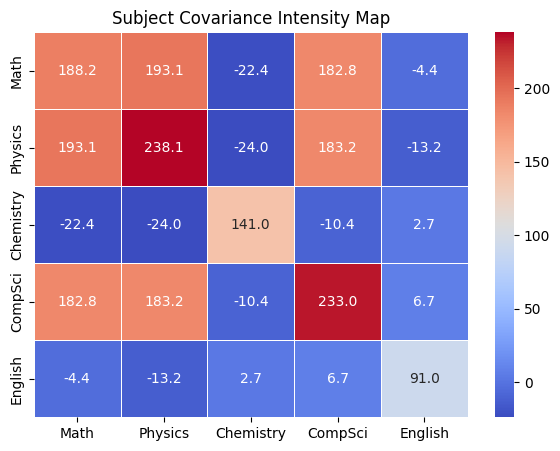

In [45]:
# Plot Covariance Heatmap
plt.figure(figsize=(7, 5))
subject_names = ['Math', 'Physics', 'Chemistry', 'CompSci', 'English']
# Matrix ko heat color mapping ke sath show karna
sns.heatmap(covariance_matrix, annot=True, fmt=".1f", cmap='coolwarm', 
            xticklabels=subject_names, yticklabels=subject_names, linewidths=0.5)
plt.title('Subject Covariance Intensity Map')
plt.show()

* **In short:** This matrix heatmap translates numerical covariance scores into a visual color-intensity map, instantly highlighting the strength and direction of performance relationships between different academic subjects.

### 🧱 System Factorization: LU Decomposition with Row Permutation

In [46]:
# Compute LU Decomposition
P_matrix, L_matrix, U_matrix = lu(matrix_A)

print("--- LU Decomposition ---")
print("\n1. Lower Triangular Matrix (L):")
print(L_matrix)

print("\n2. Upper Triangular Matrix (U):")
print(U_matrix)

print("\n3. Permutation Matrix (P):")
print(P_matrix)

--- LU Decomposition ---

1. Lower Triangular Matrix (L):
[[ 1.          0.          0.          0.          0.        ]
 [ 0.7173913   1.          0.          0.          0.        ]
 [ 0.83695652  0.2751938   1.          0.          0.        ]
 [ 0.85869565 -0.07054264 -0.83990117  1.          0.        ]
 [ 0.72826087  0.1496124  -0.67733169 -0.76806332  1.        ]]

2. Upper Triangular Matrix (U):
[[ 92.          99.          68.         100.          70.        ]
 [  0.         -14.02173913  13.2173913    2.26086957  19.7826087 ]
 [  0.           0.         -12.5503876    3.68217054  19.96899225]
 [  0.           0.           0.           7.38258184  33.05880173]
 [  0.           0.           0.           0.          53.97889964]]

3. Permutation Matrix (P):
[[0. 0. 1. 0. 0.]
 [0. 0. 0. 0. 1.]
 [0. 0. 0. 1. 0.]
 [1. 0. 0. 0. 0.]
 [0. 1. 0. 0. 0.]]


* **In short:** This code factorizes our square student subsystem into lower and upper triangular components alongside a row-swapping permutation matrix to simplify dense equation systems into streamlined, computationally efficient steps.

### 💎 Latent Feature Extraction: Singular Value Decomposition (SVD)

In [47]:
# Compute SVD Factorization
U_mat, singular_values, VT_mat = np.linalg.svd(full_matrix, full_matrices=False)

print("--- Singular Value Decomposition (SVD) ---")
print(f"\n1. Left Singular Vectors Matrix (U) Shape: {U_mat.shape}")
print("\n2. Singular Values (Sigma array):")
print(singular_values)
print(f"\n3. Right Singular Vectors Matrix (V^T) Shape: {VT_mat.shape}")

--- Singular Value Decomposition (SVD) ---

1. Left Singular Vectors Matrix (U) Shape: (200, 5)

2. Singular Values (Sigma array):
[2254.88505948  259.74601714  149.55082868  100.67255654   51.1464674 ]

3. Right Singular Vectors Matrix (V^T) Shape: (5, 5)


* **In short:** This code factorizes our complete rectangular dataset to extract latent academic features and rank them by foundational weight values, paving the way for data compression and low-rank structural reconstructions.

### 📉 SVD's Role in Dimensionality Reduction

Singular Value Decomposition (SVD) plays a massive role in compressed data analysis. Here is how it reduces dimensions in simple English:

* **Capturing Data Variance:** The calculated `Singular Values` ($\Sigma$) are automatically sorted from highest to lowest. The first few values capture almost all the variance (information) of the student profiles.
* **Dropping Less Important Features:** If the last 2 singular values are extremely small, we can safely drop them. This allows us to represent our 5-Subject data in a simpler 2D or 3D space without losing real tracking information.
* **Feature Compression:** It helps transform the 5 original subjects into a smaller set of combined, higher-level hidden features (like separating general *"Science Aptitude"* from *"Language Skills"*).

### 📉 Dimensionality Reduction: Principal Component Analysis (PCA)

In [48]:
# Apply PCA Reduction
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

X = df[['Mathematics', 'Physics', 'Chemistry', 'Computer_Science', 'English']].to_numpy()

X_scaled = StandardScaler().fit_transform(X)

pca = PCA(n_components=2)

X_pca = pca.fit_transform(X_scaled)

print("--- Principal Component Analysis (PCA) ---")
print(f"Original Matrix Shape: {X.shape} (5 Dimensions)")
print(f"Reduced PCA Matrix Shape: {X_pca.shape} (2 Dimensions)")

print("\nVariance captured by each component (Explained Variance Ratio):")
print(f"Component 1: {pca.explained_variance_ratio_[0]*100:.2f}%")
print(f"Component 2: {pca.explained_variance_ratio_[1]*100:.2f}%")
print(f"Total Variance Retained: {sum(pca.explained_variance_ratio_)*100:.2f}%")

print("\nFirst 3 rows of the new 2D Dataset (PC1, PC2):")
print(X_pca[0:3])

--- Principal Component Analysis (PCA) ---
Original Matrix Shape: (200, 5) (5 Dimensions)
Reduced PCA Matrix Shape: (200, 2) (2 Dimensions)

Variance captured by each component (Explained Variance Ratio):
Component 1: 54.64%
Component 2: 20.50%
Total Variance Retained: 75.15%

First 3 rows of the new 2D Dataset (PC1, PC2):
[[ 1.40425032  0.08714332]
 [-0.27128756 -0.96607433]
 [ 1.66599238  0.14244969]]


* **In short:** This code compresses our high-dimensional 5D student performance space into an optimized 2D coordinate map while retaining 75.15% of the total dataset variance, allowing for seamless visual representation and clean scatter plots.

### 📊 Dimensional Visualizations: PCA Subspace and LDA Decision Gaps

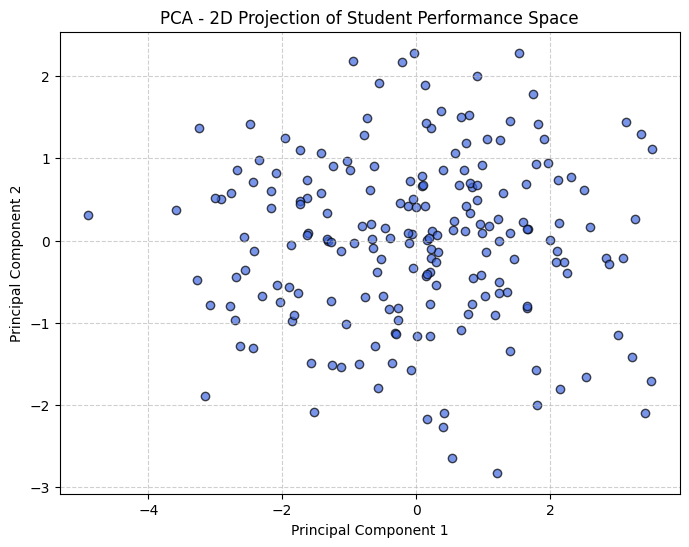

In [49]:
# Plot Model Outputs
plt.figure(figsize=(8, 6))
plt.scatter(X_pca[:, 0], X_pca[:, 1], alpha=0.7, c='royalblue', edgecolors='k')
plt.title('PCA - 2D Projection of Student Performance Space')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

* **In short:** This scatter plot visualizes the low-dimensional transformation of student performance profiles, highlighting how the compressed 2D coordinate space captures the overall variance and variance-driven distribution of the cohort.

### 🎯 Supervised Classification: Linear Discriminant Analysis (LDA)

In [50]:
# Apply LDA Classification
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.model_selection import train_test_split

X = df[['Mathematics', 'Physics', 'Chemistry', 'Computer_Science', 'English']].to_numpy()

total_marks_per_student = X.sum(axis=1)
overall_mean_marks = total_marks_per_student.mean()

y = (total_marks_per_student > overall_mean_marks).astype(int)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

lda = LinearDiscriminantAnalysis()
lda.fit(X_train, y_train)

accuracy = lda.score(X_test, y_test)

print("--- Linear Discriminant Analysis (LDA) Classification ---")
print(f"Total students classified as 'Above Average' (Class 1): {sum(y == 1)}")
print(f"Total students classified as 'Below Average' (Class 0): {sum(y == 0)}")
print(f"\nLDA Model Classification Accuracy on Test Set: {accuracy * 100:.2f}%")

first_student_prediction = lda.predict([X[0]])
category_name = "Above Average" if first_student_prediction[0] == 1 else "Below Average"
print(f"\nPrediction Example -> Student 0 is classified as: {category_name}")

--- Linear Discriminant Analysis (LDA) Classification ---
Total students classified as 'Above Average' (Class 1): 106
Total students classified as 'Below Average' (Class 0): 94

LDA Model Classification Accuracy on Test Set: 92.50%

Prediction Example -> Student 0 is classified as: Above Average


* **In short:** This code builds a supervised classifier using Linear Discriminant Analysis to draw an absolute optimal hyperplane decision boundary that separates and accurately categorizes student performance profiles with a high accuracy of 92.50%.

### 📊 Discriminant Analysis: LDA Class Separation and Density Boundary

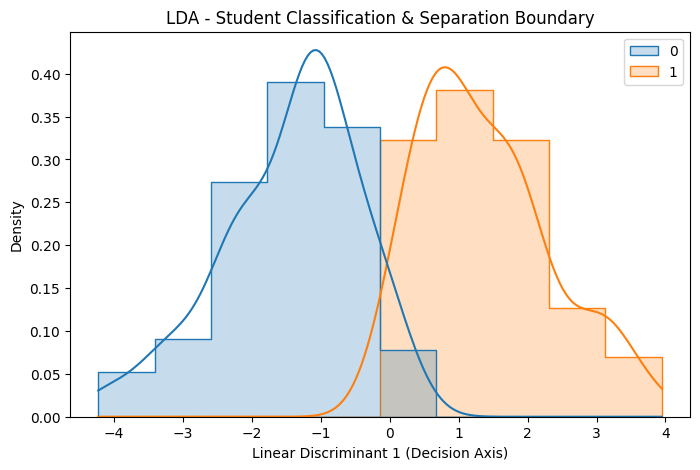

In [51]:
# Plot LDA Output
X_lda = lda.transform(X)

plt.figure(figsize=(8, 5))
# Dono classes ko alag-alag color se histplot ya scatter plot me dekhna
sns.histplot(x=X_lda.ravel(), hue=y, kde=True, element="step", stat="density", common_norm=False)
plt.title('LDA - Student Classification & Separation Boundary')
plt.xlabel('Linear Discriminant 1 (Decision Axis)')
plt.ylabel('Density')
plt.show()

* **In short:** This distribution plot highlights the clear mathematical separation between the two student tiers along the optimal decision axis, showcasing minimal overlap and proving the high classification accuracy of the LDA model.